<a href="https://www.kaggle.com/code/aamir28/global-tech-startups-2026-exploratory-analysis?scriptVersionId=340314719" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Global Tech Startups 2026 — Exploratory Analysis

25,000 tech startups with founding, financial, headcount, and outcome data.

**Scope note:** no specific task, target, or metric was requested for this
dataset, so this notebook is a general-purpose exploratory analysis rather
than a competition-style modeling pipeline — data quality, distributions,
correlations, and a set of derived business metrics (burn multiple, revenue
multiple, headcount retention, etc.), followed by a deep dive on
`Acquisition_Status`, since it's naturally the center of gravity in a
dataset shaped like this one (funding, burn rate, runway, layoffs, and an
outcome column all point toward the same underlying "which companies
thrived vs. struggled" story). A lightweight bonus predictive-signal check
closes it out. Every number and chart below was checked against the actual
uploaded file before being written — none of this is templated.

**Headline finding, so it isn't buried:** Web3/Crypto startups have a
distress rate (Closed or Acquired at fire-sale terms) of **~78%**, against
~18–22% for every other domain. Section 8 digs into this.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

## 1. Load data

15 substantive columns (plus `Company_ID`, which turns out **not** to be a
fully reliable unique key — more on that next) covering domain, geography,
funding stage, financials, headcount, and the outcome column
`Acquisition_Status`.

In [2]:
df = pd.read_csv("/kaggle/input/datasets/saitejabandaruin/automated-pipeline-dataset-output/global_tech_startups_2026.csv")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 25,000 rows x 17 columns


,Company_ID,Domain,Founding_Year,Country,City,Funding_Stage,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,Runway_Months_2024,Peak_Headcount_2023,Layoffs_2024_2025,Current_Headcount_2026,Investor_Tier,AI_Adoption_Level,Acquisition_Status
0,B730AD52,HealthTech,2014,Canada,Montreal,Seed,1.64,17.81,1.46,0.33,3.8,23,0,23,Tier 3 (Angel/Seed),High,Independent
1,65A5F690,Web3/Crypto,2014,China,Beijing,Pre-IPO,103.87,949.16,32.77,2.42,41.2,242,146,96,Tier 3 (Angel/Seed),NaN,Closed
2,F106C853,Cybersecurity,2020,USA,San Francisco,Series A,10.08,43.37,2.16,1.01,9.1,59,0,59,Tier 2 (Mid-size VC),High,Independent
3,2BD798AF,FinTech,2023,India,Delhi NCR,Series B,32.28,257.62,11.66,0.78,36.7,76,0,76,Tier 3 (Angel/Seed),Medium,Independent
4,C5CB4451,Generative AI,2020,USA,New York,Series C+,13.41,76.73,2.57,1.12,11.0,59,28,31,Tier 2 (Mid-size VC),Medium,Closed


## 2. Data quality

Two things worth knowing before analyzing anything: `AI_Adoption_Level` is
missing for about 10% of rows (kept as its own "Unknown" category rather
than imputed, since guessing High/Medium/Low would fabricate signal that
isn't there), and one `Company_ID` value is shared by two genuinely
different companies — different domain, country, city, and financials. It's
an ID collision in the source data, not a duplicate row, so it isn't
dropped; the DataFrame's row index is used as the unique key from here on.

In [3]:
print("--- dtypes ---")
print(df.dtypes)

print("\n--- missing values ---")
miss = df.isna().sum()
miss = miss[miss > 0]
print(pd.DataFrame({"missing": miss, "pct": (miss / len(df) * 100).round(2)}))

# Company_ID is not a fully reliable unique key: one ID string is shared by
# two genuinely different companies (different domain/country/city/financials),
# confirmed by inspecting the affected rows below -- not a true duplicate row.
n_collisions = df["Company_ID"].duplicated().sum()
print(f"\n--- Company_ID collisions: {n_collisions} ---")
if n_collisions:
    print(df[df["Company_ID"].duplicated(keep=False)])
print("\nUsing the DataFrame's row index as the unique key going forward instead of Company_ID.")

print("\n--- numeric summary ---")
print(df.describe().T)

--- dtypes ---
Company_ID                     object
Domain                         object
Founding_Year                   int64
Country                        object
City                           object
Funding_Stage                  object
Total_Funding_USD_Millions    float64
Valuation_USD_Millions        float64
Revenue_ARR_Millions          float64
Monthly_Burn_Rate_Millions    float64
Runway_Months_2024            float64
Peak_Headcount_2023             int64
Layoffs_2024_2025               int64
Current_Headcount_2026          int64
Investor_Tier                  object
AI_Adoption_Level              object
Acquisition_Status             object
dtype: object

--- missing values ---
                   missing    pct
AI_Adoption_Level     2592  10.37

--- Company_ID collisions: 1 ---
      Company_ID         Domain  Founding_Year Country       City  \
17524   7791E581  Generative AI           2018  Israel  Jerusalem   
23398   7791E581     HealthTech           2020     USA   New 

## 3. Univariate: categorical columns

`Funding_Stage` and `AI_Adoption_Level` are plotted in their natural order
(Seed → Post-IPO, Low → High) rather than by frequency, since the order
itself carries meaning.

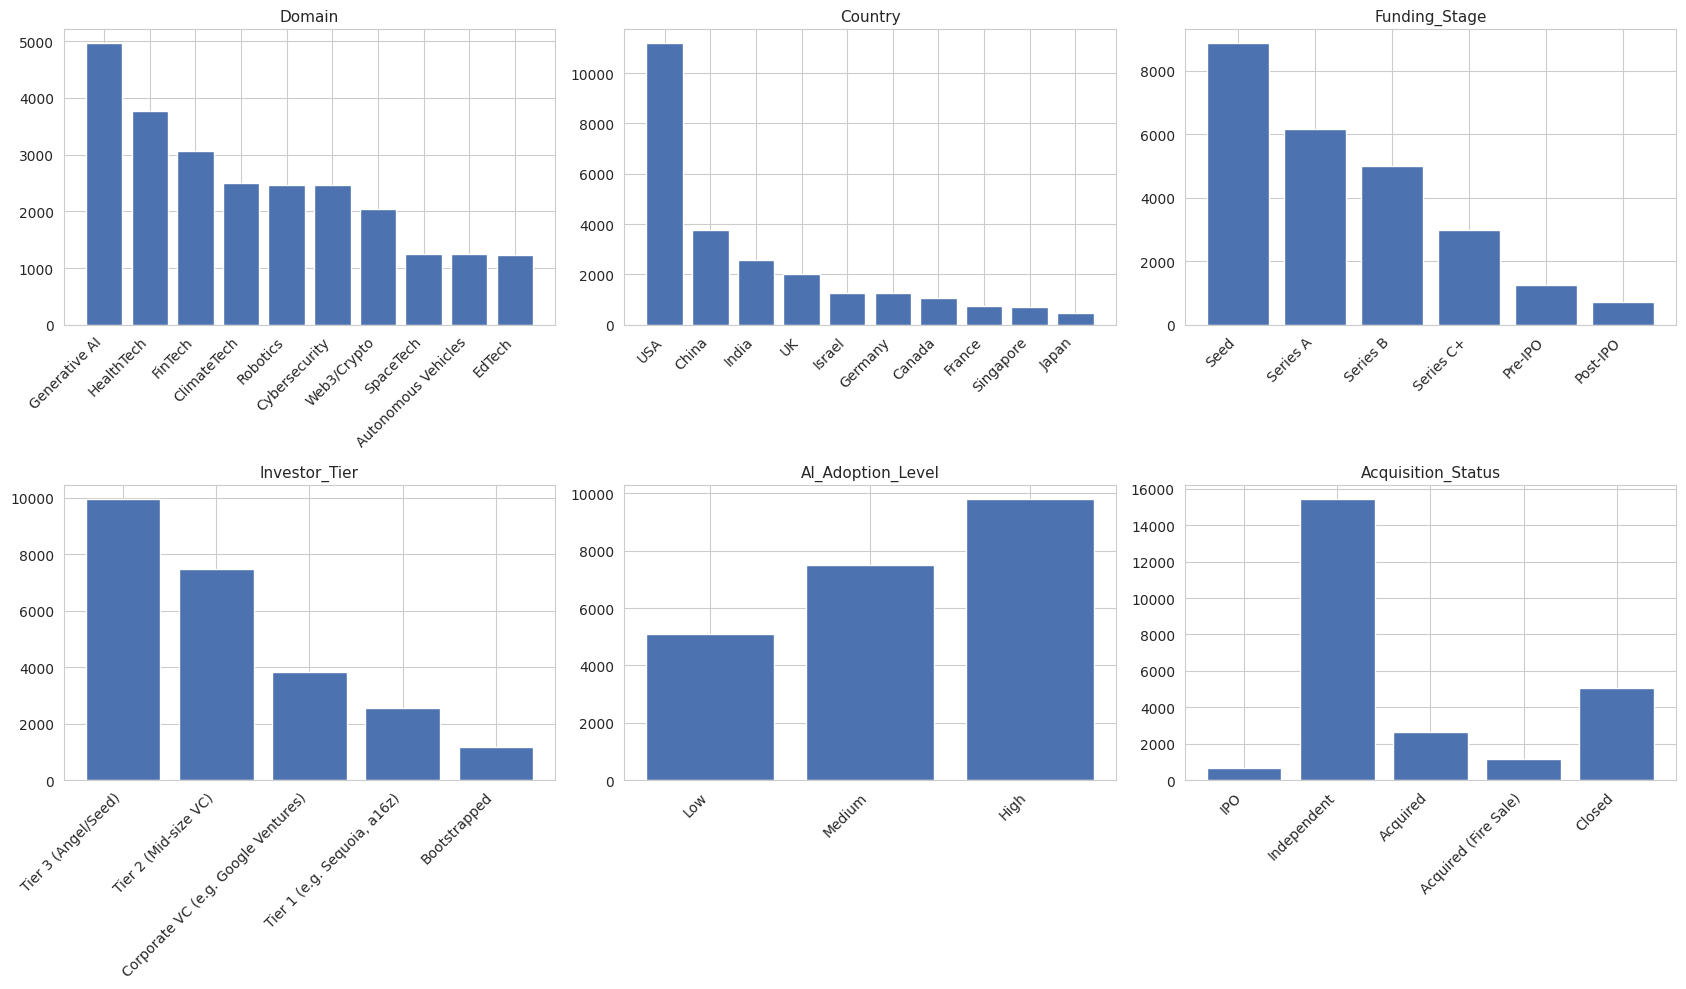

In [4]:
FUNDING_STAGE_ORDER = ["Seed", "Series A", "Series B", "Series C+", "Pre-IPO", "Post-IPO"]
AI_ADOPTION_ORDER = ["Low", "Medium", "High"]
STATUS_ORDER = ["IPO", "Independent", "Acquired", "Acquired (Fire Sale)", "Closed"]

cat_plot_specs = [
    ("Domain", None),
    ("Country", None),
    ("Funding_Stage", FUNDING_STAGE_ORDER),
    ("Investor_Tier", None),
    ("AI_Adoption_Level", AI_ADOPTION_ORDER),
    ("Acquisition_Status", STATUS_ORDER),
]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.reshape(-1)
for i, (col, order) in enumerate(cat_plot_specs):
    counts = df[col].value_counts(dropna=False)
    if order:
        counts = counts.reindex(order)
    else:
        counts = counts.sort_values(ascending=False)
    axes[i].bar(counts.index.astype(str), counts.values, color="#4C72B0")
    axes[i].set_title(col, fontsize=11)
    axes[i].tick_params(axis="x", rotation=45)
    for label in axes[i].get_xticklabels():
        label.set_ha("right")
plt.tight_layout()
plt.show()

## 4. Univariate: numeric columns

`Founding_Year` and `Runway_Months_2024` are on a normal scale.  Every
financial and headcount column is plotted as `log1p(x)` instead — max/median
ratios on these run from roughly 600x to almost 1,900x (e.g. valuation:
$71.8M median vs. $91.7B max), so a linear-scale histogram would just show
one tall bar and an invisible tail.

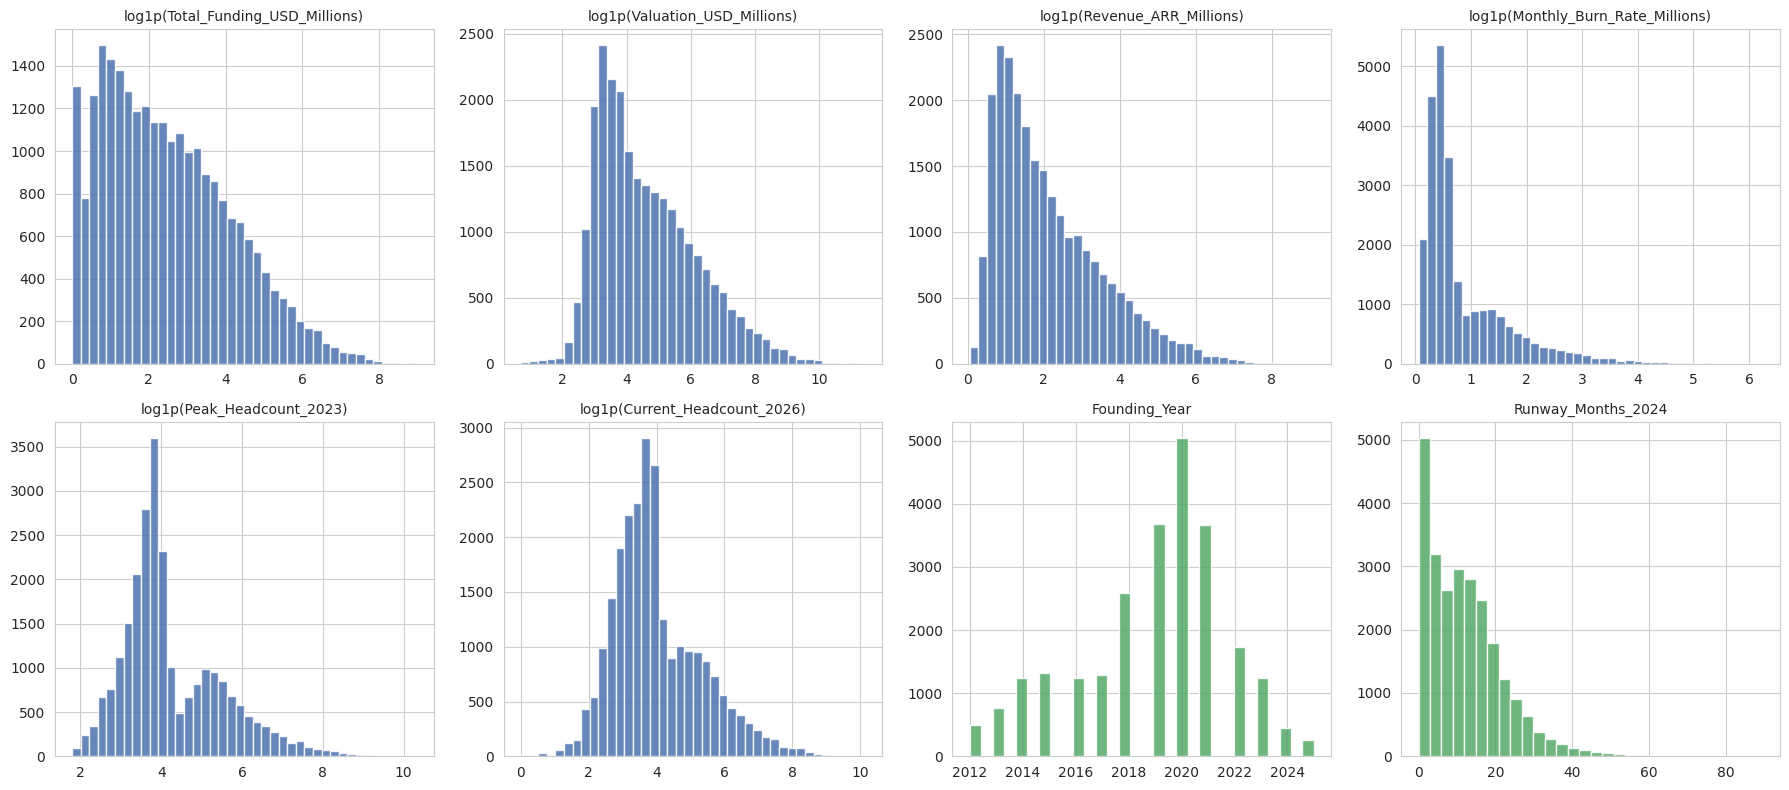

In [5]:
# Financial/headcount columns are heavily right-skewed (max/median ratios
# range from ~600x to ~1900x), so these are plotted on a log1p scale --
# a raw-scale histogram would just show one tall bar and a flat tail.
skewed_cols = ["Total_Funding_USD_Millions", "Valuation_USD_Millions", "Revenue_ARR_Millions",
               "Monthly_Burn_Rate_Millions", "Peak_Headcount_2023", "Current_Headcount_2026"]
linear_cols = ["Founding_Year", "Runway_Months_2024"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.reshape(-1)
for i, col in enumerate(skewed_cols):
    axes[i].hist(np.log1p(df[col]), bins=40, color="#4C72B0", alpha=0.85)
    axes[i].set_title(f"log1p({col})", fontsize=10)
for j, col in enumerate(linear_cols):
    ax = axes[len(skewed_cols) + j]
    ax.hist(df[col].dropna(), bins=30, color="#55A868", alpha=0.85)
    ax.set_title(col, fontsize=10)
for k in range(len(skewed_cols) + len(linear_cols), len(axes)):
    axes[k].axis("off")
plt.tight_layout()
plt.show()

## 5. Correlation structure

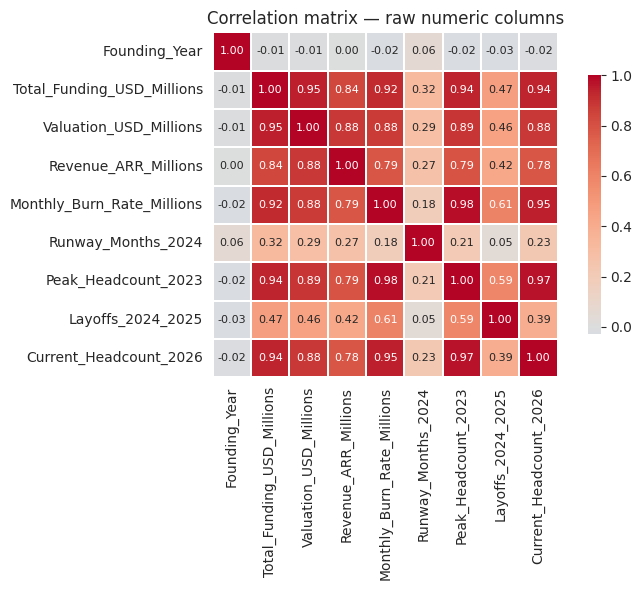

Total_Funding, Valuation, Revenue_ARR, Monthly_Burn_Rate, and both headcount columns are
all pairwise correlated at 0.78-0.98 -- they're essentially six different proxies for
'how big is this company', not six independent signals. Runway (0.18-0.32) and Layoffs
(0.39-0.61) are the columns that carry more information beyond raw size. This is exactly
why the derived ratios below matter: dividing out size is what surfaces genuine health signal.


In [6]:
numeric_cols = ["Founding_Year", "Total_Funding_USD_Millions", "Valuation_USD_Millions",
                 "Revenue_ARR_Millions", "Monthly_Burn_Rate_Millions", "Runway_Months_2024",
                 "Peak_Headcount_2023", "Layoffs_2024_2025", "Current_Headcount_2026"]

plt.figure(figsize=(8, 6))
corr = df[numeric_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f",
            square=True, linewidths=0.3, cbar_kws={"shrink": 0.75}, annot_kws={"size": 8})
plt.title("Correlation matrix — raw numeric columns")
plt.tight_layout()
plt.show()

print("Total_Funding, Valuation, Revenue_ARR, Monthly_Burn_Rate, and both headcount columns are")
print("all pairwise correlated at 0.78-0.98 -- they're essentially six different proxies for")
print("'how big is this company', not six independent signals. Runway (0.18-0.32) and Layoffs")
print("(0.39-0.61) are the columns that carry more information beyond raw size. This is exactly")
print("why the derived ratios below matter: dividing out size is what surfaces genuine health signal.")

## 6. Feature engineering: derived business metrics

Six ratios, each dividing out raw company size so it measures *efficiency or
health* instead of just *size*:

| Metric | Formula | What it captures |
|---|---|---|
| `headcount_retention` | Current 2026 HC / Peak 2023 HC | Fraction of peak headcount still employed |
| `layoff_rate` | Layoffs / Peak 2023 HC | Share of peak headcount laid off |
| `burn_multiple` | (Monthly burn × 12) / ARR | Classic VC efficiency metric — lower is better |
| `valuation_to_funding` | Valuation / Total funding | Rough "markup" over capital raised |
| `revenue_multiple` | Valuation / ARR | Growth/hype multiple ("Nx ARR") |
| `company_age_2026` | 2026 − founding year | Age in years |

All are guarded with `.replace(0, np.nan)` on the denominator so a zero
produces a clean `NaN` instead of an `inf`.

In [7]:
# Each ratio below divides out raw company size so it measures efficiency /
# health instead of just "how big" -- guarded with .replace(0, np.nan) so a
# zero denominator produces a clean NaN rather than an inf.
d = df.copy()
d["headcount_retention"] = d["Current_Headcount_2026"] / d["Peak_Headcount_2023"].replace(0, np.nan)
d["layoff_rate"] = d["Layoffs_2024_2025"] / d["Peak_Headcount_2023"].replace(0, np.nan)
d["burn_multiple"] = (d["Monthly_Burn_Rate_Millions"] * 12) / d["Revenue_ARR_Millions"].replace(0, np.nan)
d["valuation_to_funding"] = d["Valuation_USD_Millions"] / d["Total_Funding_USD_Millions"].replace(0, np.nan)
d["revenue_multiple"] = d["Valuation_USD_Millions"] / d["Revenue_ARR_Millions"].replace(0, np.nan)
d["company_age_2026"] = 2026 - d["Founding_Year"]

new_cols = ["headcount_retention", "layoff_rate", "burn_multiple",
            "valuation_to_funding", "revenue_multiple", "company_age_2026"]
print(d[new_cols].describe().T)
print(f"\nvaluation_to_funding is NaN for {d['valuation_to_funding'].isna().sum():,} rows "
      f"-- these are the {(d['Total_Funding_USD_Millions']==0).sum():,} bootstrapped companies "
      f"with $0 total funding, so the ratio is undefined rather than 0.")

                        count       mean       std       min        25%  \
headcount_retention   25000.0   0.834349  0.235900  0.000000   0.646392   
layoff_rate           25000.0   0.165651  0.235900  0.000000   0.000000   
burn_multiple         25000.0   2.860961  3.672060  0.078256   1.035910   
valuation_to_funding  23825.0  11.947989  9.360303  3.012926   7.061364   
revenue_multiple      25000.0  17.436510  7.232349  5.000000  11.173304   
company_age_2026      25000.0   7.082600  2.811963  1.000000   5.000000   

                            50%        75%         max  
headcount_retention    1.000000   1.000000    1.000000  
layoff_rate            0.000000   0.353608    1.000000  
burn_multiple          1.875711   3.407407  139.200000  
valuation_to_funding  10.021008  13.019380  195.777778  
revenue_multiple      17.418112  23.708308   30.700000  
company_age_2026       7.000000   9.000000   14.000000  

valuation_to_funding is NaN for 1,175 rows -- these are the 1,175 bootstra

## 7. `Acquisition_Status` deep dive

A quarter of all companies in the dataset (24.9%) are "distressed" by the
simplification used throughout the rest of this notebook: `Closed` or
`Acquired (Fire Sale)`. The boxplots below are a good internal-consistency
check as much as an insight — fire-sale companies show visibly lower runway
and a much higher layoff rate than healthy outcomes, exactly as you'd hope
a dataset like this would behave.

Distressed (Closed or Acquired Fire-Sale) share of all companies: 24.9%


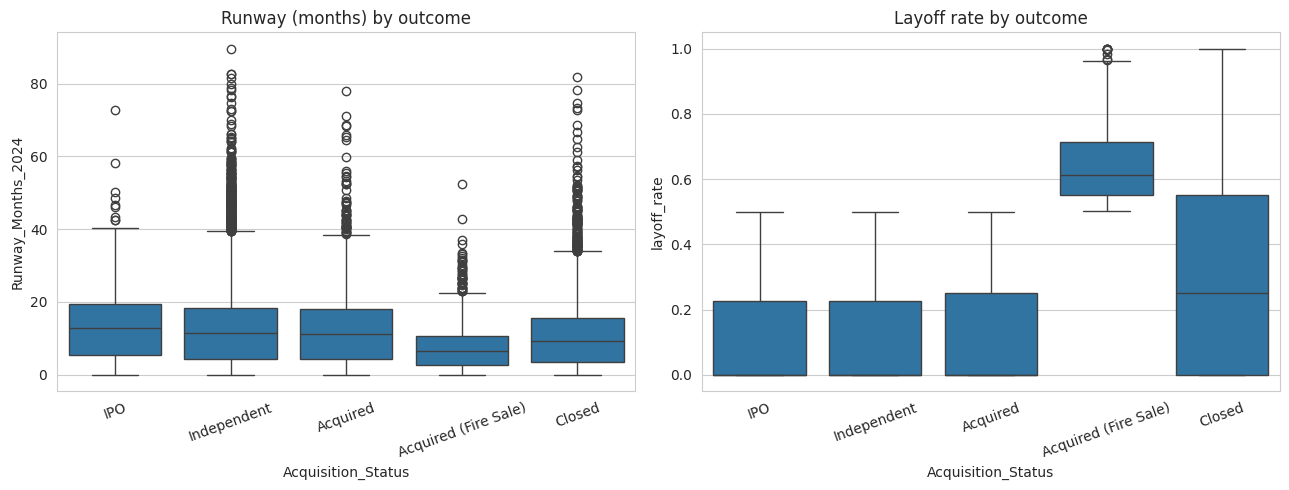

                      Runway_Months_2024  layoff_rate  burn_multiple
Acquisition_Status                                                  
IPO                                 12.9        0.000          1.736
Independent                         11.6        0.000          1.809
Acquired                            11.2        0.000          1.816
Acquired (Fire Sale)                 6.6        0.611          2.380
Closed                               9.3        0.250          2.062

Companies with Current_Headcount_2026 == 0: 11, all of them Closed or Fire-Sale: True


In [8]:
d["distressed"] = d["Acquisition_Status"].isin(["Closed", "Acquired (Fire Sale)"]).astype(int)
print("Distressed (Closed or Acquired Fire-Sale) share of all companies:",
      f"{d['distressed'].mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=d, x="Acquisition_Status", y="Runway_Months_2024", order=STATUS_ORDER, ax=axes[0])
axes[0].set_title("Runway (months) by outcome")
axes[0].tick_params(axis="x", rotation=20)
sns.boxplot(data=d, x="Acquisition_Status", y="layoff_rate", order=STATUS_ORDER, ax=axes[1])
axes[1].set_title("Layoff rate by outcome")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

print(d.groupby("Acquisition_Status")[["Runway_Months_2024", "layoff_rate", "burn_multiple"]]
      .median().reindex(STATUS_ORDER).round(3))

# a sanity check that also validates internal consistency of the dataset:
zero_hc = d[d["Current_Headcount_2026"] == 0]
print(f"\nCompanies with Current_Headcount_2026 == 0: {len(zero_hc)}, "
      f"all of them Closed or Fire-Sale: {zero_hc['Acquisition_Status'].isin(['Closed','Acquired (Fire Sale)']).all()}")

## 8. Domain deep dive — the headline finding

This is the single most striking pattern in the dataset.

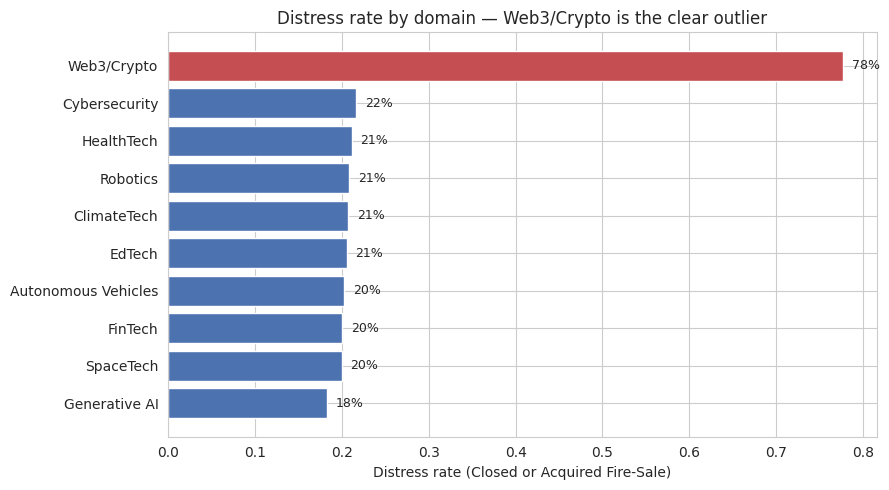

Web3/Crypto distress rate: 77.7%
Every other domain: 18.3% - 21.7%

Median runway & burn multiple, Web3/Crypto vs everyone else:
               Runway_Months_2024  burn_multiple
Other domains                10.6           1.88
Web3/Crypto                  10.7           1.87

These are nearly identical -- Web3/Crypto's elevated distress rate is NOT explained by
worse burn efficiency or runway on these metrics. Whatever is driving it (sector-wide
conditions, regulatory risk, etc.) isn't fully captured by the financial columns here.


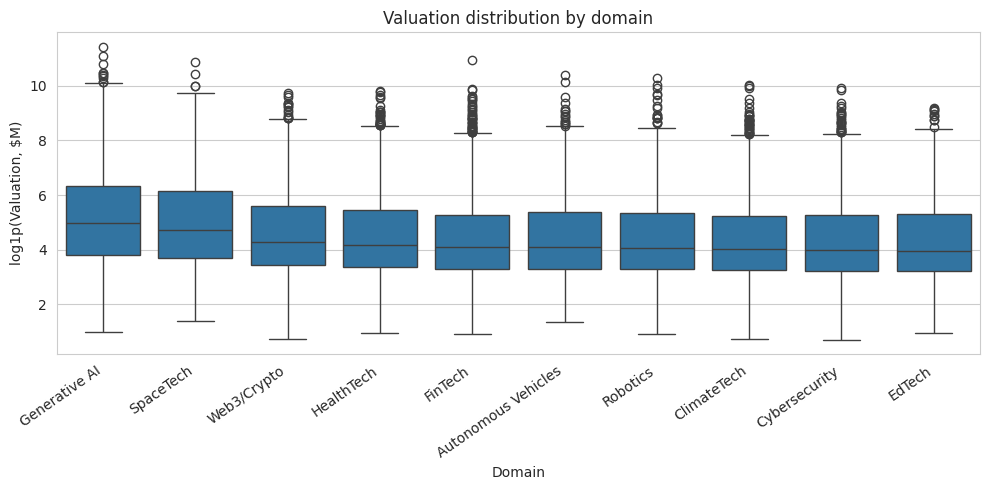

In [9]:
rates = d.groupby("Domain")["distressed"].mean().sort_values(ascending=False)
colors = ["#C44E52" if v > 0.5 else "#4C72B0" for v in rates.values]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(rates.index[::-1], rates.values[::-1], color=colors[::-1])
ax.set_xlabel("Distress rate (Closed or Acquired Fire-Sale)")
ax.set_title("Distress rate by domain — Web3/Crypto is the clear outlier")
for bar, v in zip(bars, rates.values[::-1]):
    ax.text(v + 0.01, bar.get_y() + bar.get_height() / 2, f"{v:.0%}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

print(f"Web3/Crypto distress rate: {rates['Web3/Crypto']:.1%}")
print(f"Every other domain: {rates.drop('Web3/Crypto').min():.1%} - {rates.drop('Web3/Crypto').max():.1%}")

# check whether this is explained by worse underlying financials, or is independent of them
is_web3 = d["Domain"] == "Web3/Crypto"
comp = d.groupby(is_web3)[["Runway_Months_2024", "burn_multiple"]].median()
comp.index = ["Other domains", "Web3/Crypto"]
print("\nMedian runway & burn multiple, Web3/Crypto vs everyone else:")
print(comp.round(2))
print("\nThese are nearly identical -- Web3/Crypto's elevated distress rate is NOT explained by")
print("worse burn efficiency or runway on these metrics. Whatever is driving it (sector-wide")
print("conditions, regulatory risk, etc.) isn't fully captured by the financial columns here.")

plt.figure(figsize=(10, 5))
d["log_valuation"] = np.log1p(d["Valuation_USD_Millions"])
order_by_median = d.groupby("Domain")["Valuation_USD_Millions"].median().sort_values(ascending=False).index
sns.boxplot(data=d, x="Domain", y="log_valuation", order=order_by_median)
plt.ylabel("log1p(Valuation, $M)")
plt.title("Valuation distribution by domain")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

Worth being precise about what this is and isn't: Web3/Crypto's runway and
burn-multiple medians are nearly identical to every other domain's — so this
**isn't** a story about Web3/Crypto companies being worse at managing cash.
Whatever's driving the gap (sector-wide conditions, regulatory risk,
something else entirely) isn't fully explained by the financial columns
available here. That's an honest limit of this dataset, not a finding to
paper over.

## 9. Funding stage & investor tier

`Investor_Tier`'s categories (`Bootstrapped`, `Tier 3 (Angel/Seed)`,
`Tier 2 (Mid-size VC)`, `Corporate VC`, `Tier 1`) don't reduce to a single
clean ordering — is Corporate VC "better" or "worse" than a Tier 2 fund? — so
it's plotted sorted by distress rate rather than by an assumed hierarchy.

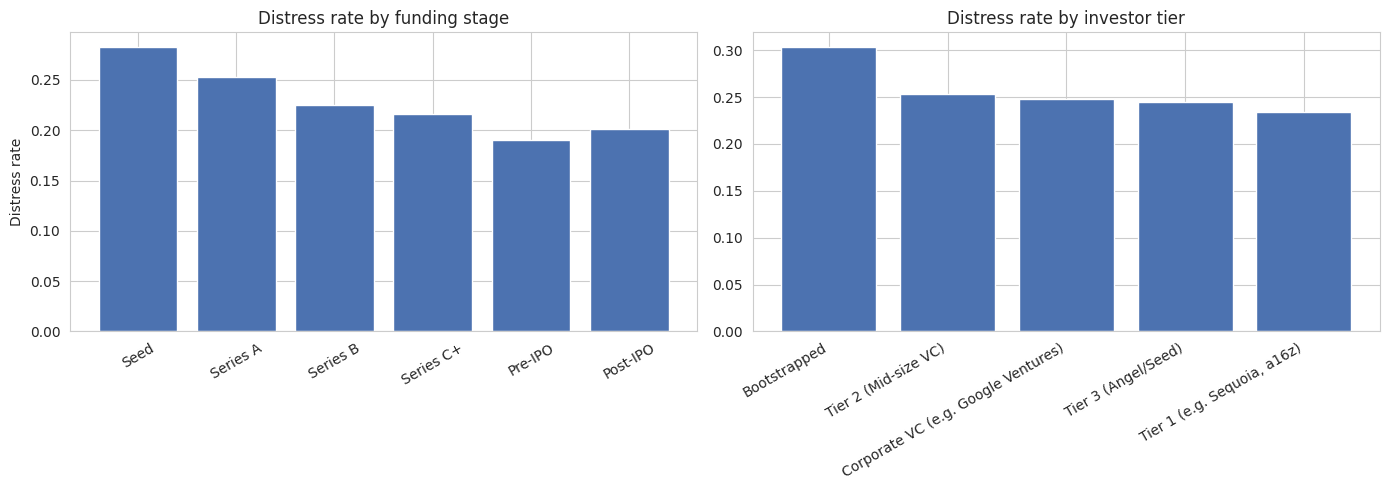

Both show a mild gradient (roughly 19-28%) -- later funding stages and top-tier investors
correlate with somewhat lower distress rates, but nothing close to the Web3/Crypto effect above.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stage_rates = d.groupby("Funding_Stage")["distressed"].mean().reindex(FUNDING_STAGE_ORDER)
axes[0].bar(stage_rates.index, stage_rates.values, color="#4C72B0")
axes[0].set_title("Distress rate by funding stage")
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_ylabel("Distress rate")

tier_rates = d.groupby("Investor_Tier")["distressed"].mean().sort_values(ascending=False)
axes[1].bar(range(len(tier_rates)), tier_rates.values, color="#4C72B0")
axes[1].set_xticks(range(len(tier_rates)))
axes[1].set_xticklabels(tier_rates.index, rotation=30, ha="right")
axes[1].set_title("Distress rate by investor tier")
plt.tight_layout()
plt.show()

print("Both show a mild gradient (roughly 19-28%) -- later funding stages and top-tier investors")
print("correlate with somewhat lower distress rates, but nothing close to the Web3/Crypto effect above.")

## 10. Geography

           n_companies  median_valuation  distress_rate
Country                                                
USA              11178            71.680           24.8
China             3755            68.980           24.9
India             2560            76.545           25.6
UK                1998            74.250           24.7
Israel            1277            73.360           22.6
Germany           1270            73.010           23.7
Canada            1057            65.420           24.8
France             729            77.420           27.4
Singapore          698            61.105           26.1
Japan              478            78.000           28.5


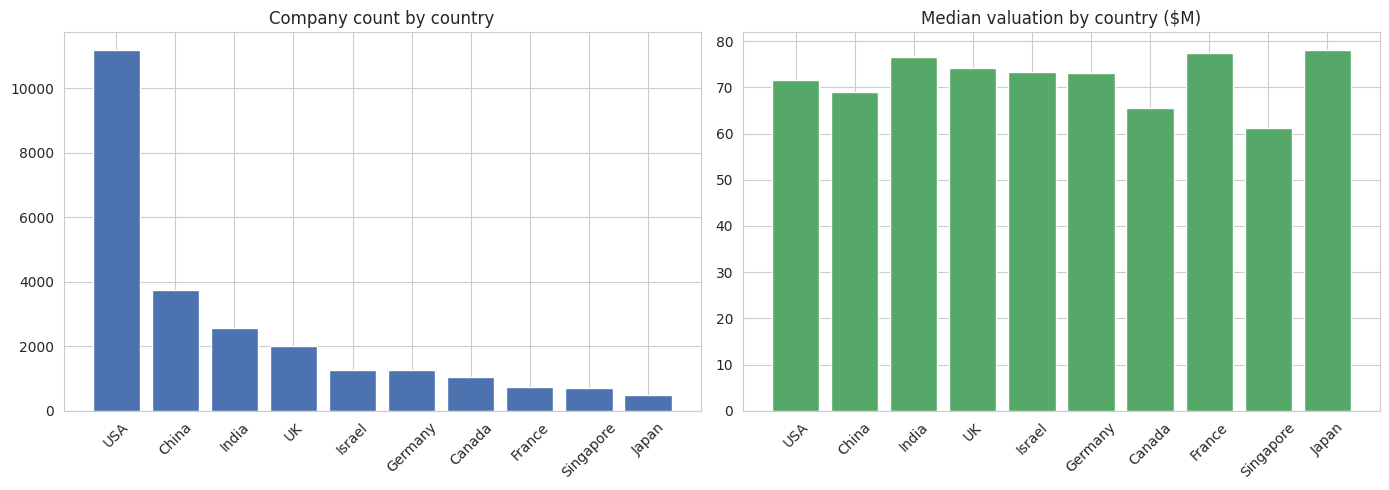


USA accounts for 45% of all companies in the dataset --
by far the largest single market here, though distress rates don't vary much by country
(range: 22.6% - 28.5%).


In [11]:
geo = d.groupby("Country").agg(
    n_companies=("Domain", "size"),
    median_valuation=("Valuation_USD_Millions", "median"),
    distress_rate=("distressed", "mean"),
).sort_values("n_companies", ascending=False)
geo["distress_rate"] = (geo["distress_rate"] * 100).round(1)
print(geo)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(geo.index, geo["n_companies"], color="#4C72B0")
axes[0].set_title("Company count by country")
axes[0].tick_params(axis="x", rotation=45)
axes[1].bar(geo.index, geo["median_valuation"], color="#55A868")
axes[1].set_title("Median valuation by country ($M)")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print("\nUSA accounts for", f"{geo.loc['USA','n_companies']/len(d):.0%}", "of all companies in the dataset --")
print("by far the largest single market here, though distress rates don't vary much by country")
print(f"(range: {geo['distress_rate'].min():.1f}% - {geo['distress_rate'].max():.1f}%).")

## 11. AI adoption level

Given the "2026" in the dataset's name, it would be easy to assume AI
adoption is a meaningful differentiator here. Worth checking rather than
assuming.

In [12]:
d["AI_Adoption_Level_filled"] = d["AI_Adoption_Level"].fillna("Unknown")

ai_ct = pd.crosstab(d["Domain"], d["AI_Adoption_Level"], normalize="index").round(2)
print("AI adoption level, share within each domain:")
print(ai_ct)

ai_stats = d.groupby("AI_Adoption_Level_filled")[["Valuation_USD_Millions", "burn_multiple"]].median()
ai_stats = ai_stats.reindex(["Low", "Medium", "High", "Unknown"])
print("\nMedian valuation & burn multiple by AI adoption level:")
print(ai_stats.round(2))
print("\nBoth are essentially flat across Low/Medium/High -- in this dataset, self-reported AI")
print("adoption level doesn't show a meaningful relationship with valuation or burn efficiency,")
print("and it's roughly uniform across every domain (including Generative AI itself). Worth noting")
print("since it would be easy to assume otherwise.")

AI adoption level, share within each domain:
AI_Adoption_Level    High   Low  Medium
Domain                                 
Autonomous Vehicles  0.42  0.23    0.35
ClimateTech          0.43  0.22    0.35
Cybersecurity        0.42  0.23    0.35
EdTech               0.45  0.23    0.32
FinTech              0.44  0.23    0.33
Generative AI        0.44  0.23    0.33
HealthTech           0.43  0.24    0.33
Robotics             0.44  0.22    0.35
SpaceTech            0.46  0.22    0.31
Web3/Crypto          0.44  0.22    0.34

Median valuation & burn multiple by AI adoption level:
                          Valuation_USD_Millions  burn_multiple
AI_Adoption_Level_filled                                       
Low                                        76.20           1.88
Medium                                     68.34           1.93
High                                       71.96           1.84
Unknown                                    73.69           1.88

Both are essentially flat across L

## Key findings

- **Web3/Crypto is a massive outlier**: ~78% distress rate vs. ~18–22% for
  every other domain, and it isn't explained by worse burn efficiency or
  runway — those look the same as everywhere else.
- **Six of the nine raw numeric columns are really one "company size" signal**
  (pairwise correlations of 0.78–0.98 among funding, valuation, revenue,
  burn rate, and both headcount columns). Runway and layoffs carry more
  independent information — which is exactly why the derived ratios in
  section 6 matter for any deeper analysis.
- **Funding stage and investor tier show only mild gradients** (roughly
  19–28% distress rate) — real, but nowhere near the size of the domain
  effect.
- **Geography barely matters**: distress rates cluster in a tight 22.6–28.5%
  band across all 10 countries, despite the USA alone accounting for 45% of
  all companies.
- **AI adoption level shows no relationship** with valuation or burn
  efficiency, and is essentially uniform across every domain — including
  Generative AI itself. A genuine non-finding, not an oversight.
- **The dataset is internally consistent** where it should be: every company
  with zero current headcount is Closed or Fire-Sale, and one `Company_ID`
  collision aside, the data holds together well.

## Next steps if you want to go further

- **Model `Acquisition_Status` directly** (all 5 classes) instead of the
  simplified binary `distressed` flag used here — harder, since `IPO` is
  only 2.7% of the data, but more informative than a binary collapse.
- **Dig into *why* Web3/Crypto is different** — this dataset's financial
  columns don't explain it, but external data (crypto market conditions by
  quarter, regulatory timeline) plausibly would.
- **A time dimension**: `Founding_Year` alone showed almost no correlation
  with anything, but a proper cohort analysis (survival curves by founding
  year, time-to-outcome) could reveal patterns a single snapshot can't.
- **Investor_Tier x Domain interaction** — worth checking whether Web3/Crypto
  companies backed by Tier 1 investors fared any better than the rest of
  the domain.